In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

import time

In [2]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

print("Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully!
X shape: (150, 4)
y shape: (150,)


In [3]:
print("First 5 rows:")
display(X.head())

print("\nDataset information:")
print(X.info())

print("\nMissing values:")
print(X.isnull().sum())

print("\nStatistical summary:")
display(X.describe())

print("\nClass distribution:")
print(y.value_counts())

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (150, 4)
Scaled shape: (150, 4)


In [5]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("Explained variance ratio:")
for i, value in enumerate(explained_variance, start=1):
    print(f"PC{i}: {value:.4f}")

print("\nCumulative explained variance:")
print(np.cumsum(explained_variance))

Explained variance ratio:
PC1: 0.7296
PC2: 0.2285
PC3: 0.0367
PC4: 0.0052

Cumulative explained variance:
[0.72962445 0.95813207 0.99482129 1.        ]


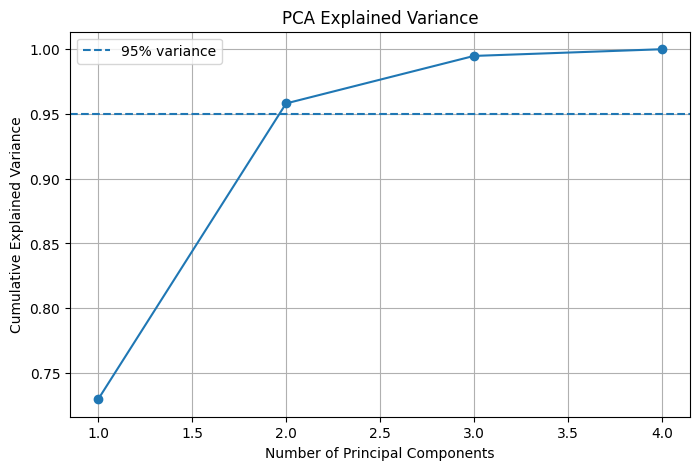

In [6]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid()

plt.show()

In [7]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal number of PCA components:", n_components)

Optimal number of PCA components: 2


In [8]:
pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])
print("PCA shape:", X_pca.shape)

Original dimensions: 4
PCA dimensions: 2
PCA shape: (150, 2)


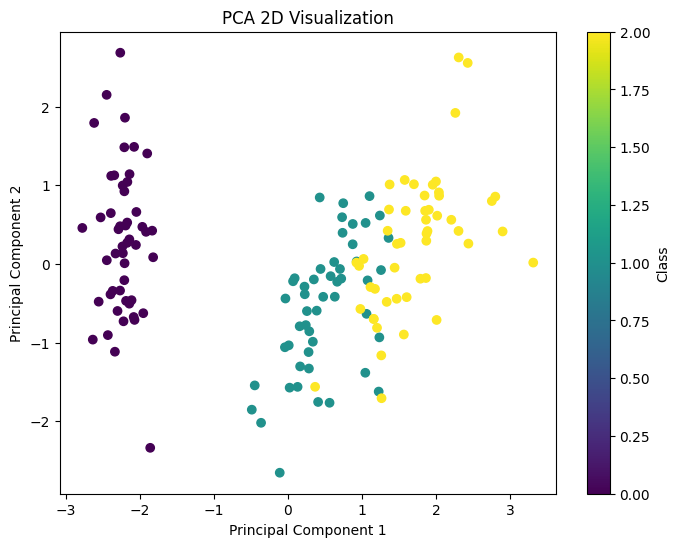

In [9]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")

plt.colorbar(scatter, label="Class")

plt.show()

In [10]:
results = []

perplexities = [5, 30, 50]
learning_rates = [50, 200, 500]

for perplexity in perplexities:
    for learning_rate in learning_rates:

        start_time = time.time()

        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=learning_rate,
            max_iter=1000,
            random_state=42
        )

        X_tsne_temp = tsne.fit_transform(X_scaled)

        elapsed_time = time.time() - start_time

        score = silhouette_score(X_tsne_temp, y)

        results.append({
            "perplexity": perplexity,
            "learning_rate": learning_rate,
            "silhouette_score": score,
            "execution_time": elapsed_time
        })

results_df = pd.DataFrame(results)

display(results_df)

,perplexity,learning_rate,silhouette_score,execution_time
0,5,50,0.406997,1.210469
1,5,200,0.303565,1.146177
2,5,500,0.054564,1.468394
3,30,50,0.529671,2.445962
4,30,200,0.529486,2.544512
5,30,500,0.311206,0.689623
6,50,50,0.505710,0.657101
7,50,200,0.509145,0.793134
8,50,500,0.543769,0.799563


In [11]:
best_result = results_df.loc[
    results_df["silhouette_score"].idxmax()
]

print("Best t-SNE parameters:")
print(best_result)

Best t-SNE parameters:
perplexity           50.000000
learning_rate       500.000000
silhouette_score      0.543769
execution_time        0.799563
Name: 8, dtype: float64


In [12]:
best_perplexity = int(best_result["perplexity"])
best_learning_rate = float(best_result["learning_rate"])

start_time = time.time()

tsne = TSNE(
    n_components=2,
    perplexity=best_perplexity,
    learning_rate=best_learning_rate,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_time = time.time() - start_time

print("t-SNE completed successfully!")
print("t-SNE shape:", X_tsne.shape)
print("Execution time:", round(tsne_time, 3), "seconds")

t-SNE completed successfully!
t-SNE shape: (150, 2)
Execution time: 1.458 seconds


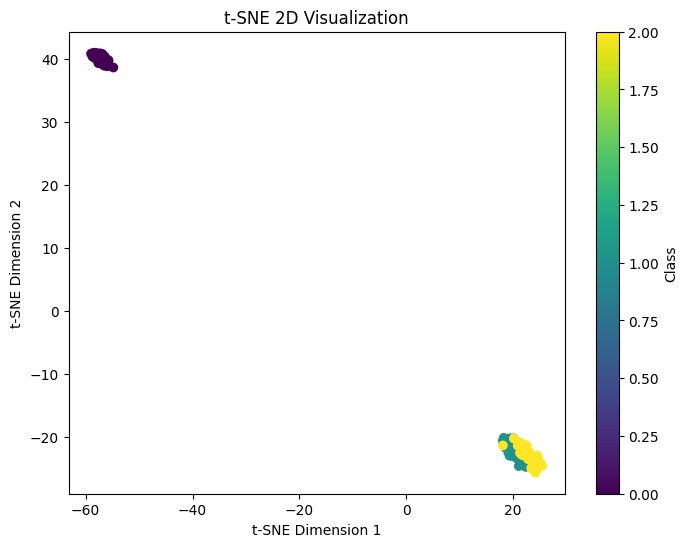

In [13]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="viridis"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE 2D Visualization")

plt.colorbar(scatter, label="Class")

plt.show()

In [14]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train_original.shape[0])
print("Testing samples:", X_test_original.shape[0])

Training samples: 120
Testing samples: 30


In [15]:
start_time = time.time()

model_original = LogisticRegression(max_iter=1000)

model_original.fit(
    X_train_original,
    y_train
)

y_pred_original = model_original.predict(
    X_test_original
)

original_time = time.time() - start_time

original_accuracy = accuracy_score(
    y_test,
    y_pred_original
)

print("Original Data Accuracy:",
      round(original_accuracy, 4))

print("Execution Time:",
      round(original_time, 4),
      "seconds")

Original Data Accuracy: 0.9333
Execution Time: 0.0194 seconds


In [16]:
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

start_time = time.time()

model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(
    X_pca_train,
    y_pca_train
)

y_pred_pca = model_pca.predict(
    X_pca_test
)

pca_time = time.time() - start_time

pca_accuracy = accuracy_score(
    y_pca_test,
    y_pred_pca
)

print("PCA Accuracy:",
      round(pca_accuracy, 4))

print("Execution Time:",
      round(pca_time, 4),
      "seconds")

PCA Accuracy: 0.9
Execution Time: 0.0546 seconds


In [17]:
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

start_time = time.time()

model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(
    X_pca_train,
    y_pca_train
)

y_pred_pca = model_pca.predict(
    X_pca_test
)

pca_time = time.time() - start_time

pca_accuracy = accuracy_score(
    y_pca_test,
    y_pred_pca
)

print("PCA Accuracy:",
      round(pca_accuracy, 4))

print("Execution Time:",
      round(pca_time, 4),
      "seconds")

PCA Accuracy: 0.9
Execution Time: 0.0089 seconds


In [18]:
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    X_tsne,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

start_time = time.time()

model_tsne = LogisticRegression(max_iter=1000)

model_tsne.fit(
    X_tsne_train,
    y_tsne_train
)

y_pred_tsne = model_tsne.predict(
    X_tsne_test
)

tsne_classifier_time = time.time() - start_time

tsne_accuracy = accuracy_score(
    y_tsne_test,
    y_pred_tsne
)

print("t-SNE Accuracy:",
      round(tsne_accuracy, 4))

print("Execution Time:",
      round(tsne_classifier_time, 4),
      "seconds")

t-SNE Accuracy: 0.9667
Execution Time: 0.5697 seconds


In [19]:
comparison = pd.DataFrame({
    "Method": [
        "Original Data",
        "PCA",
        "t-SNE"
    ],

    "Dimensions": [
        X_scaled.shape[1],
        X_pca.shape[1],
        X_tsne.shape[1]
    ],

    "Accuracy": [
        original_accuracy,
        pca_accuracy,
        tsne_accuracy
    ],

    "Execution Time (seconds)": [
        original_time,
        pca_time,
        tsne_classifier_time
    ]
})

display(comparison)

,Method,Dimensions,Accuracy,Execution Time (seconds)
0,Original Data,4,0.933333,0.019392
1,PCA,2,0.900000,0.008851
2,t-SNE,2,0.966667,0.569700


In [20]:
print("========== ORIGINAL DATA ==========")
print(classification_report(y_test, y_pred_original))

print("========== PCA ==========")
print(classification_report(y_pca_test, y_pred_pca))

print("========== t-SNE ==========")
print(classification_report(y_tsne_test, y_pred_tsne))

========== ORIGINAL DATA ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

========== PCA ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

========== t-SNE ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      

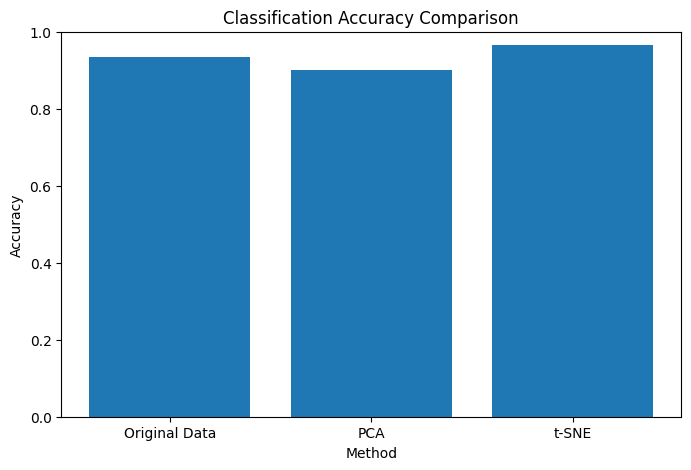

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Accuracy"]
)

plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Comparison")

plt.ylim(0, 1)

plt.show()

In [22]:
import os

project_path = "/content/dimensionality_reduction_project"

os.makedirs(project_path + "/notebooks", exist_ok=True)
os.makedirs(project_path + "/docs", exist_ok=True)
os.makedirs(project_path + "/assets/plots", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [23]:
import os

for root, dirs, files in os.walk("/content/dimensionality_reduction_project"):
    level = root.replace("/content/dimensionality_reduction_project", "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")
    for file in files:
        print(indent + "    " + file)

dimensionality_reduction_project/
    notebooks/
    docs/
    assets/
        plots/


In [25]:
plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/pca_2d.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

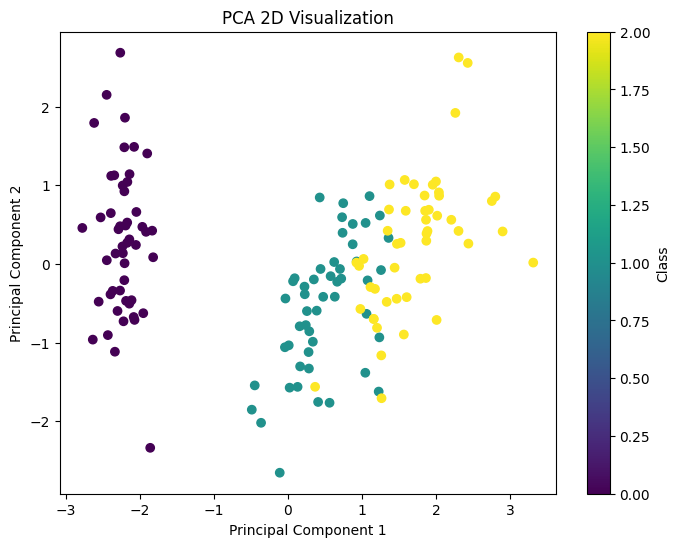

PCA plot saved successfully!


In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")

plt.colorbar(scatter, label="Class")

plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/pca_2d.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("PCA plot saved successfully!")

In [27]:
import os

print("Checking project folder...")

print(os.listdir("/content/dimensionality_reduction_project"))
print(os.listdir("/content/dimensionality_reduction_project/assets"))
print(os.listdir("/content/dimensionality_reduction_project/assets/plots"))

Checking project folder...
['notebooks', 'docs', 'assets']
['plots']
['pca_2d.png']


In [28]:
plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/pca_2d.png",
    dpi=180,
    bbox_inches="tight"
)

print("PCA plot saved successfully!")

PCA plot saved successfully!


<Figure size 640x480 with 0 Axes>

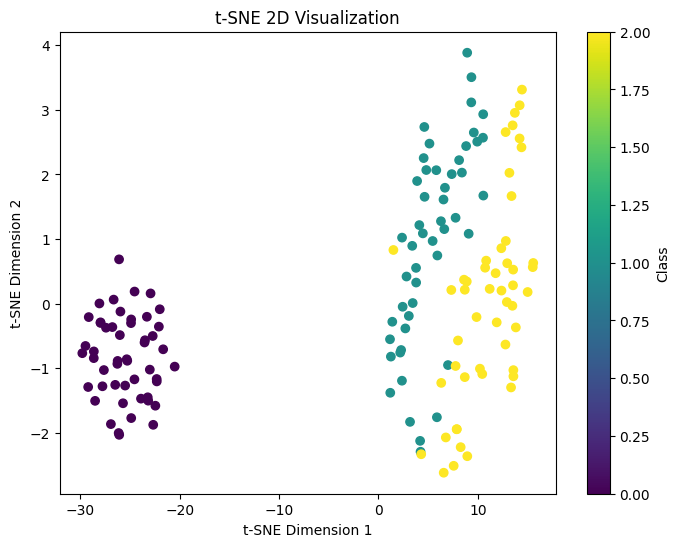

tsne_2d.png created successfully!


In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=50,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="viridis"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE 2D Visualization")

plt.colorbar(scatter, label="Class")

plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/tsne_2d.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("tsne_2d.png created successfully!")

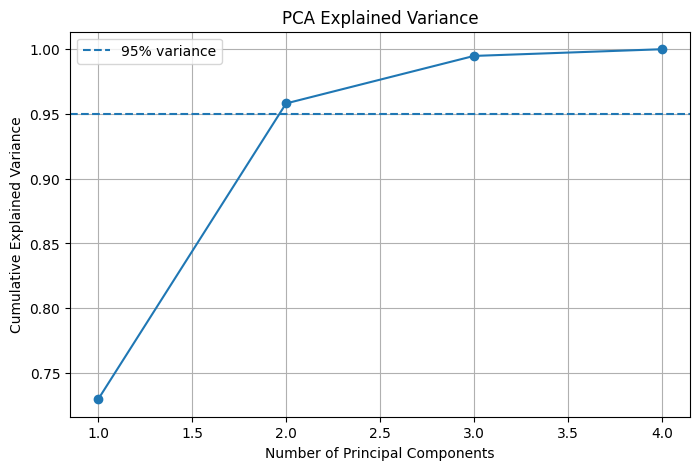

pca_explained_variance.png created successfully!


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.legend()
plt.grid()

plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/pca_explained_variance.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("pca_explained_variance.png created successfully!")

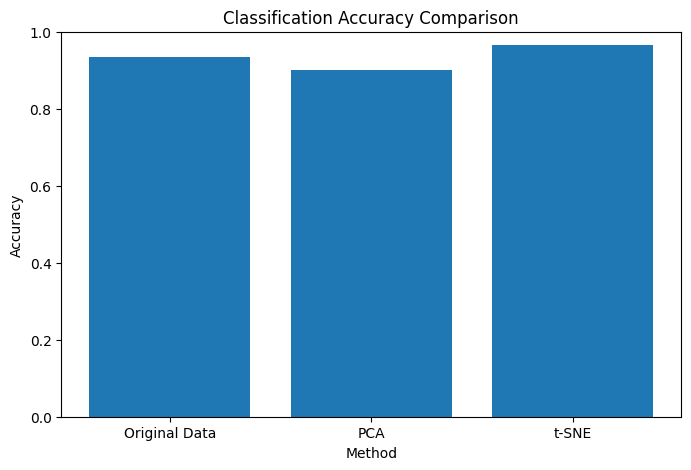

Accuracy Comparison
-------------------
Original Data: 0.9333
PCA: 0.9
t-SNE: 0.9667

accuracy_comparison.png created successfully!


In [31]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split original data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Original data
model_original = LogisticRegression(max_iter=1000)
model_original.fit(X_train, y_train)

pred_original = model_original.predict(X_test)

accuracy_original = accuracy_score(
    y_test,
    pred_original
)

# PCA data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_pca_train, y_pca_train)

pred_pca = model_pca.predict(X_pca_test)

accuracy_pca = accuracy_score(
    y_pca_test,
    pred_pca
)

# t-SNE data
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    X_tsne,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_tsne = LogisticRegression(max_iter=1000)
model_tsne.fit(X_tsne_train, y_tsne_train)

pred_tsne = model_tsne.predict(X_tsne_test)

accuracy_tsne = accuracy_score(
    y_tsne_test,
    pred_tsne
)

# Accuracy comparison
methods = [
    "Original Data",
    "PCA",
    "t-SNE"
]

accuracies = [
    accuracy_original,
    accuracy_pca,
    accuracy_tsne
]

plt.figure(figsize=(8, 5))

plt.bar(methods, accuracies)

plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Comparison")

plt.ylim(0, 1)

plt.savefig(
    "/content/dimensionality_reduction_project/assets/plots/accuracy_comparison.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Accuracy Comparison")
print("-------------------")
print("Original Data:", round(accuracy_original, 4))
print("PCA:", round(accuracy_pca, 4))
print("t-SNE:", round(accuracy_tsne, 4))

print("\naccuracy_comparison.png created successfully!")

In [33]:
readme = '''
# Dimensionality Reduction using PCA and t-SNE

## Project Overview

This project demonstrates dimensionality reduction using Principal
Component Analysis (PCA) and t-SNE on the Iris dataset.

## Dataset

The Iris dataset contains:
- 150 samples
- 4 numerical features
- 3 classes

## Methods Used

1. Exploratory Data Analysis
2. Feature Standardization
3. Principal Component Analysis (PCA)
4. t-SNE
5. 2D Visualization
6. Logistic Regression Classification
7. Performance Comparison

## Visualizations

The project includes:
- PCA 2D visualization
- t-SNE 2D visualization
- PCA explained variance plot
- Classification accuracy comparison

## Project Structure

README.md
requirements.txt
notebooks/dimensionality_reduction.ipynb
docs/comparative_report.md
assets/plots/

## Conclusion

PCA reduces the number of dimensions while preserving important
variance in the dataset. t-SNE is useful for visualizing high-dimensional
data in two dimensions.

## Note

t-SNE is mainly intended for visualization. Its classification
comparison in this project is exploratory.
'''

with open(
    "/content/dimensionality_reduction_project/README.md",
    "w"
) as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [34]:
report = """# Comparative Report: PCA vs t-SNE

## 1. Introduction

This project investigates dimensionality reduction using Principal
Component Analysis (PCA) and t-SNE on the Iris dataset.

## 2. Dataset

The Iris dataset contains 150 samples, 4 numerical features,
and 3 different classes.

## 3. Exploratory Data Analysis

The dataset was examined for:
- Dataset dimensions
- Missing values
- Statistical summary
- Class distribution

No missing values were found in the dataset.

## 4. Data Preprocessing

The numerical features were standardized using StandardScaler
before applying PCA and t-SNE.

## 5. PCA

Principal Component Analysis was applied to reduce the number of
dimensions.

The cumulative explained variance was examined to determine an
appropriate number of components.

A PCA explained-variance plot and a 2D PCA visualization were created.

## 6. t-SNE

t-SNE was used to create a two-dimensional representation of the
dataset.

Different values of perplexity and learning rate were tested.

The t-SNE visualization was created to examine the separation of
the three Iris classes.

## 7. Classification

Logistic Regression was used to compare classification performance
on:

1. Original data
2. PCA-reduced data
3. t-SNE-reduced data

## 8. Visualizations

The following plots are included in the assets/plots folder:

- pca_2d.png
- tsne_2d.png
- pca_explained_variance.png
- accuracy_comparison.png

## 9. Performance Comparison

Classification accuracy was compared between the original data,
PCA-reduced data, and t-SNE-reduced data.

The accuracy comparison plot is included in the project assets.

## 10. PCA vs t-SNE

PCA is a linear dimensionality reduction technique that can be
used for feature transformation while preserving a selected
amount of variance.

t-SNE is mainly designed for visualization and is useful for
examining local structure and patterns in high-dimensional data.

## 11. Limitations

Standard t-SNE does not provide the same straightforward transform
operation for new unseen samples as PCA. Therefore, the t-SNE
classification experiment should be considered exploratory.

## 12. Conclusion

The project demonstrates the use of PCA and t-SNE for dimensionality
reduction and visualization. PCA provides a compact representation
based on explained variance, while t-SNE provides a useful
two-dimensional visualization of the dataset.
"""

with open(
    "/content/dimensionality_reduction_project/docs/comparative_report.md",
    "w"
) as f:
    f.write(report)

print("comparative_report.md created successfully!")

comparative_report.md created successfully!


In [35]:
requirements = """numpy
pandas
matplotlib
scikit-learn
jupyter
"""

file_path = "/content/dimensionality_reduction_project/requirements.txt"

with open(file_path, "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")
print("Location:", file_path)

requirements.txt created successfully!
Location: /content/dimensionality_reduction_project/requirements.txt


In [36]:
import os

project = "/content/dimensionality_reduction_project"

for root, dirs, files in os.walk(project):
    level = root.replace(project, "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    for file in sorted(files):
        print(indent + "    " + file)

dimensionality_reduction_project/
    README.md
    requirements.txt
    notebooks/
    docs/
        comparative_report.md
    assets/
        plots/
            accuracy_comparison.png
            pca_2d.png
            pca_explained_variance.png
            tsne_2d.png


In [37]:
import os
import shutil

project = "/content/dimensionality_reduction_project"

# Make sure required folders exist
os.makedirs(project + "/notebooks", exist_ok=True)
os.makedirs(project + "/docs", exist_ok=True)
os.makedirs(project + "/assets/plots", exist_ok=True)

# Move README.md from notebooks to main project folder
wrong_readme = project + "/notebooks/README.md"
correct_readme = project + "/README.md"

if os.path.exists(wrong_readme):
    shutil.move(wrong_readme, correct_readme)
    print("Moved README.md to main project folder.")

# Move requirements.txt from notebooks to main project folder
wrong_requirements = project + "/notebooks/requirements.txt"
correct_requirements = project + "/requirements.txt"

if os.path.exists(wrong_requirements):
    shutil.move(wrong_requirements, correct_requirements)
    print("Moved requirements.txt to main project folder.")

print("\nFolder cleanup completed!")


Folder cleanup completed!


In [38]:
import os

project = "/content/dimensionality_reduction_project"

print("FINAL PROJECT STRUCTURE\n")

for root, dirs, files in os.walk(project):
    level = root.replace(project, "").count(os.sep)
    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    for file in sorted(files):
        print(indent + "    " + file)

FINAL PROJECT STRUCTURE

dimensionality_reduction_project/
    README.md
    requirements.txt
    notebooks/
    docs/
        comparative_report.md
    assets/
        plots/
            accuracy_comparison.png
            pca_2d.png
            pca_explained_variance.png
            tsne_2d.png
